# 1. Exploration initiale du jeu de radiographies

Objectif : importer les données fournies, vérifier la structure des fichiers, contrôler la résolution et les canaux couleur des images, puis afficher quelques exemples visuels.

In [ ]:
# Importer les bibliothèques nécessaires
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
# Chemins
DATA_DIR = Path("data/raw")
LABELED_DIR = DATA_DIR / "avec_labels"
UNLABELED_DIR = DATA_DIR / "sans_label"

print("Dossier data :", DATA_DIR.resolve())
print("Existe :", DATA_DIR.exists())
print("Dossier avec labels :", LABELED_DIR.exists())
print("Dossier sans label :", UNLABELED_DIR.exists())

Dossier data : C:\Users\louis\Documents_locaux\LC_10\data\raw
Existe : True
Dossier avec labels : True
Dossier sans label : True


In [5]:
# Lister les images dans le dossier data
image_paths = sorted(DATA_DIR.rglob("*.jpg"))

print("Nombre total d'images :", len(image_paths))
print("Exemple de fichier :", image_paths[0])

Nombre total d'images : 1506
Exemple de fichier : data\raw\avec_labels\cancer\05340cd4-3bb2-459d-9937-bf27d52d8351.jpg


In [6]:
# Tableau de synthèse des images
records = []

for path in image_paths:
    if "avec_labels" in path.parts:
        split = "avec_labels"
        label = path.parent.name
    elif "sans_label" in path.parts:
        split = "sans_label"
        label = "unknown"
    else:
        split = "unknown"
        label = "unknown"

    records.append({
        "path": path,
        "filename": path.name,
        "split": split,
        "label": label,
        "extension": path.suffix.lower()
    })

df = pd.DataFrame(records)
df.head()

,path,filename,split,label,extension
0,data\raw\avec_labels\cancer\05340cd4-3bb2-459d...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,avec_labels,cancer,.jpg
1,data\raw\avec_labels\cancer\0c6f3641-60d9-4a76...,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,avec_labels,cancer,.jpg
2,data\raw\avec_labels\cancer\0f718241-8f63-4b55...,0f718241-8f63-4b55-81ce-315324b51069.jpg,avec_labels,cancer,.jpg
3,data\raw\avec_labels\cancer\11a7a426-4806-401e...,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,avec_labels,cancer,.jpg
4,data\raw\avec_labels\cancer\1c043dbb-4623-4769...,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,avec_labels,cancer,.jpg


In [7]:
# Vue d'ensemble des labels
print("Nombre total d'images :", len(df))

display(df["split"].value_counts())
display(df["label"].value_counts())
display(df["extension"].value_counts())

Nombre total d'images : 1506


split
sans_label     1406
avec_labels     100
Name: count, dtype: int64

label
unknown    1406
cancer       50
normal       50
Name: count, dtype: int64

extension
.jpg    1506
Name: count, dtype: int64

In [8]:
# Résolution des images et erreurs éventuelles
image_info = []
errors = []

for path in image_paths:
    try:
        with Image.open(path) as img:
            image_info.append({
                "path": path,
                "width": img.width,
                "height": img.height,
                "mode": img.mode,
                "format": img.format
            })
    except Exception as e:
        errors.append({
            "path": path,
            "error": str(e)
        })

info_df = pd.DataFrame(image_info)
errors_df = pd.DataFrame(errors)

print("Images lisibles :", len(info_df))
print("Images illisibles :", len(errors_df))

display(info_df.head())

Images lisibles : 1506
Images illisibles : 0


,path,width,height,mode,format
0,data\raw\avec_labels\cancer\05340cd4-3bb2-459d...,512,512,RGB,JPEG
1,data\raw\avec_labels\cancer\0c6f3641-60d9-4a76...,512,512,RGB,JPEG
2,data\raw\avec_labels\cancer\0f718241-8f63-4b55...,512,512,RGB,JPEG
3,data\raw\avec_labels\cancer\11a7a426-4806-401e...,512,512,RGB,JPEG
4,data\raw\avec_labels\cancer\1c043dbb-4623-4769...,512,512,RGB,JPEG


In [9]:
# Synthèse technique des images
print("Résolutions détectées :")
display(info_df[["width", "height"]].value_counts().reset_index(name="count"))

print("Modes couleur détectés :")
display(info_df["mode"].value_counts())

print("Formats détectés :")
display(info_df["format"].value_counts())

Résolutions détectées :


,width,height,count
0,512,512,1506


Modes couleur détectés :


mode
RGB    1506
Name: count, dtype: int64

Formats détectés :


format
JPEG    1506
Name: count, dtype: int64

In [ ]:
# Fusionner les informations techniques avec le DataFrame principal
df = df.merge(info_df, on="path", how="left")
df.head()

,path,filename,split,label,extension,width,height,mode,format
0,data\raw\avec_labels\cancer\05340cd4-3bb2-459d...,05340cd4-3bb2-459d-9937-bf27d52d8351.jpg,avec_labels,cancer,.jpg,512,512,RGB,JPEG
1,data\raw\avec_labels\cancer\0c6f3641-60d9-4a76...,0c6f3641-60d9-4a76-abe5-de89d55d5f2c.jpg,avec_labels,cancer,.jpg,512,512,RGB,JPEG
2,data\raw\avec_labels\cancer\0f718241-8f63-4b55...,0f718241-8f63-4b55-81ce-315324b51069.jpg,avec_labels,cancer,.jpg,512,512,RGB,JPEG
3,data\raw\avec_labels\cancer\11a7a426-4806-401e...,11a7a426-4806-401e-98b2-b96e7094d1a6.jpg,avec_labels,cancer,.jpg,512,512,RGB,JPEG
4,data\raw\avec_labels\cancer\1c043dbb-4623-4769...,1c043dbb-4623-4769-8e5e-0223bd745040.jpg,avec_labels,cancer,.jpg,512,512,RGB,JPEG


In [12]:
# Visualisation des images
def show_images(paths, title, n_cols=5):
    n_images = len(paths)
    n_rows = (n_images + n_cols - 1) // n_cols

    plt.figure(figsize=(n_cols * 3, n_rows * 3))

    for i, path in enumerate(paths):
        img = Image.open(path)

        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(img)
        plt.title(path.parent.name)
        plt.axis("off")

    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

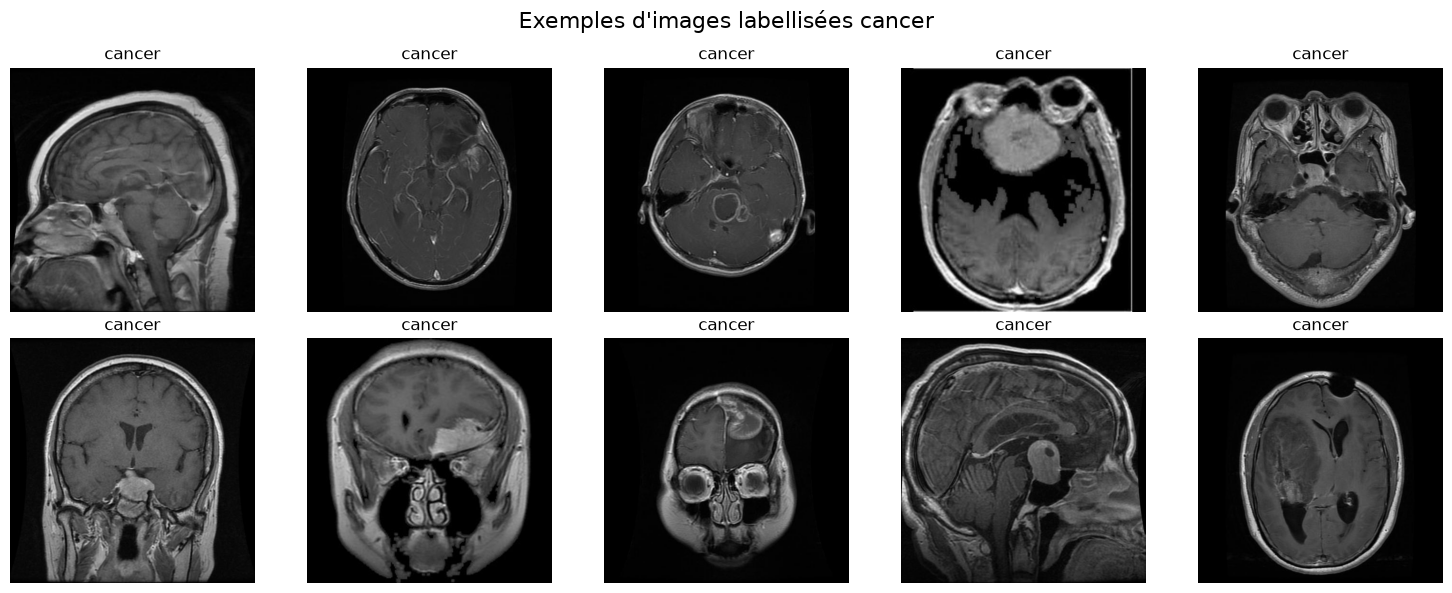

In [13]:
# ... avec cancer
cancer_examples = df[df["label"] == "cancer"]["path"].head(10).tolist()
show_images(cancer_examples, "Exemples d'images labellisées cancer")

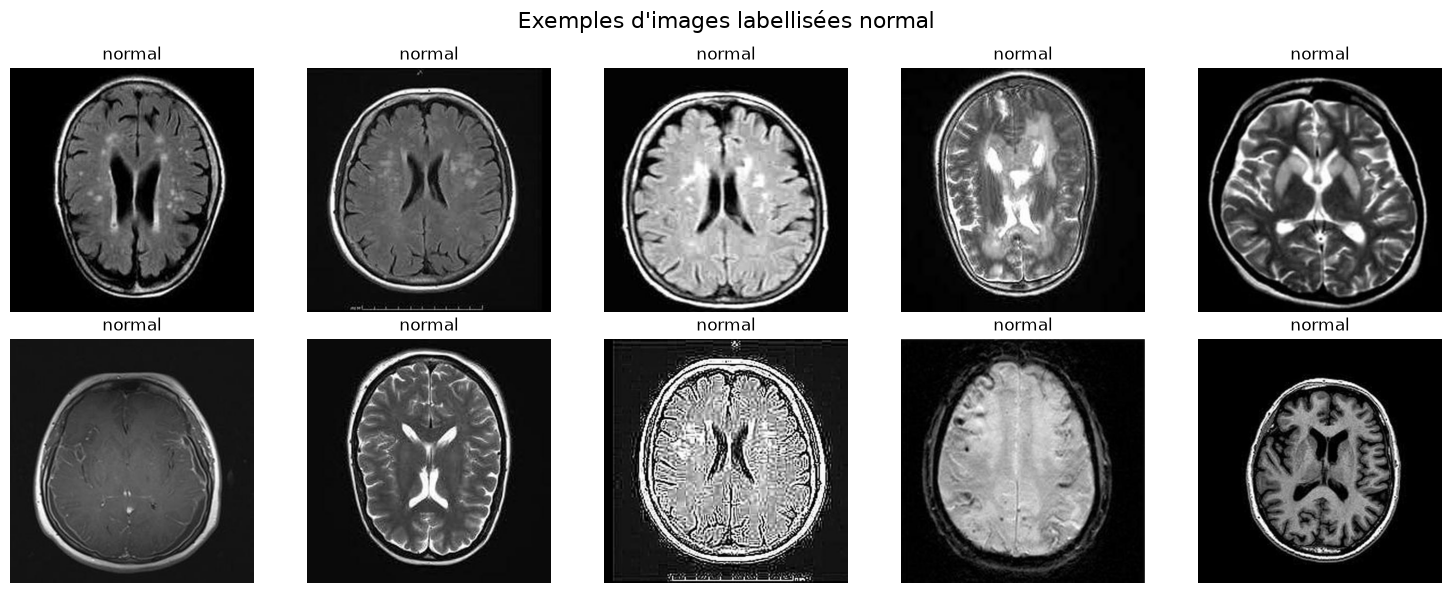

In [15]:
# ... normal
normal_examples = df[df["label"] == "normal"]["path"].head(10).tolist()
show_images(normal_examples, "Exemples d'images labellisées normal")

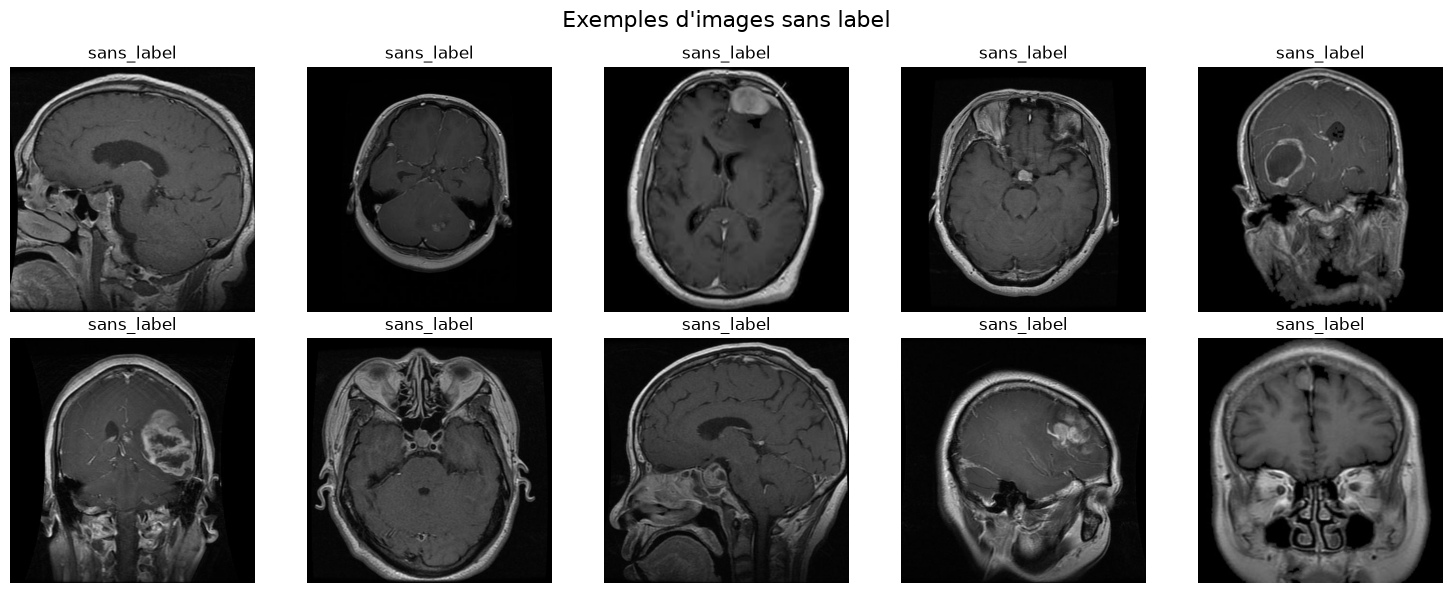

In [16]:
# ... sans label
unlabeled_examples = df[df["label"] == "unknown"]["path"].head(10).tolist()
show_images(unlabeled_examples, "Exemples d'images sans label")

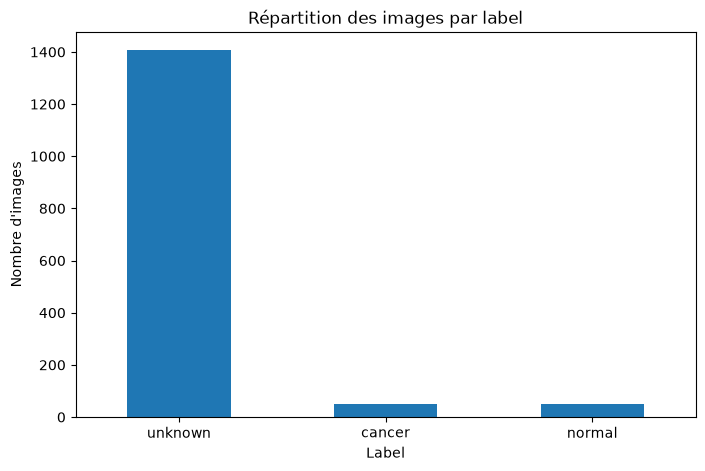

In [18]:
# Visualiser la répartition
label_counts = df["label"].value_counts()

plt.figure(figsize=(8, 5))
label_counts.plot(kind="bar")
plt.title("Répartition des images par label")
plt.xlabel("Label")
plt.ylabel("Nombre d'images")
plt.xticks(rotation=0)
plt.show()

## Observations

Le jeu de données contient 1506 images au total.

La structure est composée de deux ensembles :
- 100 images labellisées dans `data/raw/avec_labels`
- 1406 images non labellisées dans `data/raw/sans_label`

Les images labellisées sont équilibrées :
- 50 images `cancer`
- 50 images `normal`

Toutes les images analysées sont lisibles, au format JPG, en mode RGB, avec une résolution homogène de 512 x 512 pixels.

Point d’attention : le mail initial mentionne des images PNG, mais le dataset local contient des fichiers JPG. Cette différence devra être signalée dans la synthèse projet.

La faible quantité d’images labellisées rend pertinente une approche semi-supervisée ou pseudo-labellisée pour exploiter les 1406 images sans label.

## Definition of Done - Étape 1

L’étape 1 est considérée comme terminée si :

- les données sont accessibles localement ;
- la structure des dossiers est comprise ;
- le nombre total d’images est vérifié ;
- la répartition entre images labellisées et non labellisées est documentée ;
- la distribution des classes `normal` et `cancer` est vérifiée ;
- la résolution, le format et le mode couleur des images sont contrôlés ;
- plusieurs exemples visuels sont affichés ;
- les premières observations et anomalies éventuelles sont notées.